# 03c — Conventional energy resolution: fixed-energy beams & Crystal-Ball fits

[`03_ml_training_and_eval.ipynb`](03_ml_training_and_eval.ipynb) measured the energy
resolution the *modern* way — it trained a neural quantile ensemble on a continuous energy
spectrum and read the resolution off a Neyman band. This notebook measures the **same
quantity the conventional way**, the method calorimeter groups have used at test beams for
decades:

1. Simulate photons at a **handful of fixed energies** — a mono-energetic "beam" at each
   point, not a spectrum.
2. At each energy, histogram the detector response and **fit a Crystal-Ball function**
   (a Gaussian core with a low-side power-law tail).
3. Quote the **Gaussian-core width σ** as the resolution at that energy.
4. **Invert the calibration** to turn that width into an energy resolution σ_E/E, and plot
   it against energy — then confront it with the textbook
   $\sigma_E/E = a/\sqrt{E}\oplus b\oplus c/E$.

Everything here is deliberately transparent: no training, no black box — just a fit and a
curve you can read by eye. The point is twofold: it is **ground truth** for a calorimeter,
and it is an **independent cross-check** of the ML surrogate in nb03. Where the two methods
agree, both are validated; where they disagree, that is physics (saturation, non-Gaussian
tails), not a bug.

**Kernel**: `Key4hep (CPU)`.
**Input**: per-energy extracted observables in `models/mono_<particle>/` — one `.npz` per
fixed-energy run. Generate the beams in
[`00_simulate_your_samples.ipynb`](00_simulate_your_samples.ipynb) (a fixed
`CALOMAPS_GUN_ENERGY_GEV` per energy), then extract the four readouts per energy with
`analysis/extract_readouts.py` — the batch/per-energy form of the
[`02_data_extraction.ipynb`](02_data_extraction.ipynb) readouts; its docstring has the exact
loop. (nb02 itself writes a *single* spectrum file, so it can't produce these per-energy
inputs directly.)
**Output**: the calibration, inversion, and resolution figures below.

## 0. Choose your particle

The **one cell you change**. Everything downstream — which per-energy dataset directory is
read — derives from `PARTICLE`. Run it for photons and for pions and compare: hadronic
showers are broader and leak more, so expect a worse resolution and a larger constant term.

In [1]:
# ---- THE ONE KNOB ----
PARTICLE = "gamma"          # "gamma" or "pi+"
PART_TAG = "gamma" if PARTICLE == "gamma" else "piplus"
print(f"PARTICLE = {PARTICLE!r}  ->  reading models/mono_{PART_TAG}/")

PARTICLE = 'gamma'  ->  reading models/mono_gamma/


## 1. Setup

Repo-root self-location (works from a GUI kernel, which does not inherit a sourced
terminal's environment), the shared readout palette (matches `analysis/dashboard.py`), and
the per-energy data directory. Point `CALOMAPS_MONO_DIR` elsewhere if your fixed-energy
`.npz` live outside `models/`.

In [2]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import crystalball, norm
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

def _calomaps_home():
    h = os.environ.get("CALOMAPS_HOME")
    if h and os.path.isdir(os.path.join(h, "geometry")):
        return h
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.isdir(os.path.join(p, "geometry")) and os.path.isdir(os.path.join(p, "sim")):
            return p
        p = os.path.dirname(p)
    return os.path.expanduser("~/CALOMAPS")
CALOMAPS_HOME = _calomaps_home()
MONO_DIR = os.environ.get("CALOMAPS_MONO_DIR",
                          os.path.join(CALOMAPS_HOME, "models", f"mono_{PART_TAG}"))

# four readouts, increasing digitization (palette matches analysis/dashboard.py)
KEYS   = {"Analog": "all_visible", "MIP": "all_mip", "Hits": "all_hits", "Cluster": "all_cluster"}
COLORS = {"Analog": "royalblue", "MIP": "forestgreen", "Hits": "crimson", "Cluster": "darkorchid"}
LABELS = {"Analog": "True Analog", "MIP": "MIP counting", "Hits": "Raw Hits", "Cluster": "Naive 2D Clustering"}
METHODS = list(KEYS)
print(f"CALOMAPS_HOME = {CALOMAPS_HOME}")
print(f"MONO_DIR      = {MONO_DIR}")

CALOMAPS_HOME = /Users/murtazas/nashome/CALOMAPS
MONO_DIR      = /Users/murtazas/nashome/CALOMAPS/models/mono_gamma


## 2. Why fixed-energy beams, not a spectrum?

Energy resolution is a statement about fluctuations **at a given energy**: fire many
identical particles of energy $E$ and the detector responds a little differently each time
(shower-to-shower fluctuations, sampling, leakage). The **width** of that response, divided
by its mean, is the resolution at $E$.

On a *spectrum* every event has a different true energy, so the spread you see mixes the
detector resolution together with the spread of input energies — you cannot read one off
without disentangling the other. nb03 disentangles it by **training a model** on the whole
spectrum. The conventional alternative is simply to **remove the mixing at the source**:
pin the beam to one energy, so the response spread is purely the detector. Repeat at several
energies and you map out resolution vs energy directly.

That is exactly what a test beam does at CERN or Fermilab — a tagged, mono-energetic beam at
a few momenta. We reproduce it in simulation with a mono-energetic particle gun
(`CALOMAPS_GUN_ENERGY_GEV` in `sim/run_sim.py`), one dataset per energy. For a photon the
truth energy is then a spike: $E_{\rm true}=|\vec p|$ exactly. (The gun pins the *momentum*,
so for a massive particle like a pion the true energy is $\sqrt{p^2+m^2}$ — slightly above
$|p|$ at low momentum — and each point should be labelled by that true energy; the extractor
handles this.)

## 3. Why a Crystal Ball, and the fitter

At fixed energy the response is **not** a clean Gaussian. Sampling fluctuations and,
especially, **shower leakage** (energy escaping the readout region) pull a tail toward
*low* response. Fit a pure Gaussian and that tail drags the width up and the mean down.

The **Crystal-Ball** function is the standard fix: a Gaussian core smoothly joined to a
power-law tail below $\mu-\alpha\sigma$,

$$f(x)\propto\begin{cases}\exp\!\left(-\tfrac12 t^2\right) & t> -\alpha\\[2pt]
A\,(B-t)^{-n} & t\le -\alpha\end{cases},\qquad t=\frac{x-\mu}{\sigma}.$$

We quote the **core width $\sigma$** — the genuine resolution — and let the tail absorb the
leakage separately. (`scipy.stats.crystalball` names the two tail parameters `beta` $\equiv\alpha$
— where the tail starts — and `m` $\equiv n$ — how steep it is.) `fit_response()` does a binned
fit and **degrades gracefully** to a Gaussian, then to mean/RMS, when a distribution is too small,
too narrow, or **too discrete** for a stable 5-parameter fit — e.g. hit/cluster counts at 1–2 GeV
are small-integer, Poisson-like distributions for which a low-side tail is simply the wrong shape,
so we quote their RMS instead.

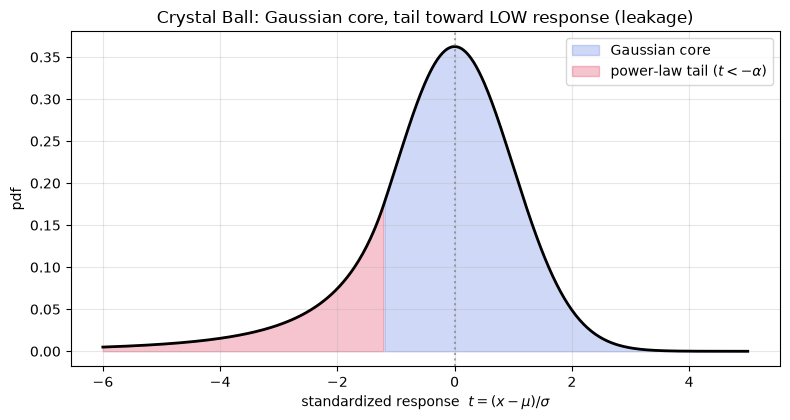

In [3]:
def fit_response(values, nbins=40, min_events=300):
    """Binned single-sided (low-tail) Crystal-Ball fit of a response distribution.
    Returns dict(mu, sigma, sigma_err, beta, m, model, ok, n). Never raises. The
    graceful-degrade ladder is Crystal Ball -> Gaussian -> mean/RMS, and it triggers on
    DISCRETENESS too: small-integer count distributions (hit/cluster counts at very low
    energy) are Poisson-like, not a low-side-tail shape, so a CB is the wrong model and we
    quote the RMS instead. sigma_err is the fit uncertainty on the width (from the
    covariance), used to put error bars on the resolution and weight the sqrt(E) fit."""
    v = np.asarray(values, float); v = v[np.isfinite(v)]
    n = v.size
    out = {"n": n, "ok": False, "model": "none", "mu": np.nan, "sigma": np.nan,
           "sigma_err": np.nan, "beta": np.nan, "m": np.nan}
    def rms():
        m_, s_ = float(np.mean(v)), float(np.std(v))
        out.update(mu=m_, sigma=s_, sigma_err=s_ / np.sqrt(2 * max(n, 1)), model="rms", ok=s_ > 0)
        return out
    if n < min_events or np.ptp(v) == 0:
        return rms() if n else out
    # discreteness guard: too few distinct values (or small-integer counts) -> RMS, not CB
    nuniq = np.unique(v).size
    if nuniq < 12 or (np.allclose(v, np.round(v)) and nuniq < 25):
        return rms()
    lo, hi = np.percentile(v, [0.3, 99.7])
    if hi <= lo:
        return rms()
    counts, edges = np.histogram(v, bins=nbins, range=(lo, hi))
    centers = 0.5 * (edges[:-1] + edges[1:]); bw = edges[1] - edges[0]
    med = float(np.median(v)); mad = float(np.median(np.abs(v - med))) * 1.4826
    sig0 = min(max(mad if mad > 0 else float(np.std(v)), bw), hi - lo)   # keep p0 inside bounds
    N0 = n * bw; yerr = np.sqrt(counts + 1.0)
    def cb(x, N, beta, mm, loc, scale):
        with np.errstate(over="ignore", invalid="ignore"):
            return N * crystalball.pdf(x, beta, mm, loc=loc, scale=scale)
    try:
        p, pcov = curve_fit(cb, centers, counts, p0=[N0, 1.5, 5.0, med, sig0], sigma=yerr,
                            absolute_sigma=True,
                            bounds=([0, 0.1, 1.001, lo, 1e-9], [np.inf, 25, 20, hi, hi - lo]),
                            maxfev=30000)
        N, beta, mm, loc, scale = p
        serr = float(np.sqrt(pcov[4, 4])) if np.all(np.isfinite(pcov)) else scale / np.sqrt(2 * n)
        # reject a runaway fit (core wider than the mean is not a sensible resolution -- happens
        # for a bimodal / non-single-peaked response, e.g. a hadron punching through)
        if 0 < scale < min(hi - lo, loc) and beta > 0.11 and lo < loc < hi:
            out.update(mu=float(loc), sigma=float(scale), sigma_err=serr, beta=float(beta),
                       m=float(mm), model="crystalball", ok=True)
            return out
    except Exception:
        pass
    def gau(x, N, loc, scale):
        return N * norm.pdf(x, loc=loc, scale=scale)
    try:
        p, pcov = curve_fit(gau, centers, counts, p0=[N0, med, sig0], sigma=yerr,
                            absolute_sigma=True, bounds=([0, lo, 1e-9], [np.inf, hi, hi - lo]),
                            maxfev=30000)
        serr = float(np.sqrt(pcov[2, 2])) if np.all(np.isfinite(pcov)) else p[2] / np.sqrt(2 * n)
        if 0 < p[2] < p[1]:                              # same sanity gate: sigma < mu
            out.update(mu=float(p[1]), sigma=float(p[2]), sigma_err=serr, model="gaussian", ok=True)
            return out
    except Exception:
        pass
    return rms()

# the shape: Gaussian core + low-side power-law tail
xx = np.linspace(-6, 5, 500); beta_d, m_d = 1.2, 4.0
yy = crystalball.pdf(xx, beta_d, m_d)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(xx, yy, color="k", lw=2)
ax.fill_between(xx, yy, where=(xx > -beta_d), color="royalblue", alpha=0.25, label="Gaussian core")
ax.fill_between(xx, yy, where=(xx <= -beta_d), color="crimson", alpha=0.25, label=r"power-law tail ($t<-\alpha$)")
ax.axvline(0, color="gray", ls=":", alpha=0.7)
ax.set_xlabel(r"standardized response  $t=(x-\mu)/\sigma$"); ax.set_ylabel("pdf")
ax.set_title(r"Crystal Ball: Gaussian core, tail toward LOW response (leakage)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Load the fixed-energy runs

Each `.npz` in `MONO_DIR` is one mono-energetic beam: aligned per-event arrays of the four
readouts, `all_truth` (a spike at the beam energy), and a scalar `E_nominal`. We sort by
energy and confirm each run really is mono-energetic (`std(all_truth)` ≈ 0).

In [4]:
def load_per_energy(datadir):
    files = sorted(glob.glob(os.path.join(datadir, "*.npz")))
    if not files:
        raise FileNotFoundError("\n".join([
            f"No per-energy .npz in {datadir}.",
            "Generate fixed-energy beams (nb00, one CALOMAPS_GUN_ENERGY_GEV per energy), then run",
            "analysis/extract_readouts.py on each to write",
            "models/mono_<tag>/decal_mono_<tag>_E####GeV.npz (see that script's docstring for the",
            "exact loop), then set CALOMAPS_MONO_DIR."]))
    pts = []
    for f in files:
        d = np.load(f)
        E = float(d["E_nominal"]) if "E_nominal" in d.files else float(np.median(d["all_truth"]))
        obs = {name: np.asarray(d[KEYS[name]], float) for name in METHODS}
        pts.append({"E": E, "obs": obs, "n": int(np.size(d["all_truth"])),
                    "tstd": float(np.std(d["all_truth"]))})
    pts.sort(key=lambda t: t["E"])
    return pts

points = load_per_energy(MONO_DIR)
E_pts = np.array([p["E"] for p in points])
print(f"{len(points)} fixed-energy runs from {MONO_DIR}:")
for p in points:
    print(f"  E = {p['E']:6.1f} GeV   N = {p['n']:5d}   std(truth) = {p['tstd']:.3g} GeV")

9 fixed-energy runs from /Users/murtazas/nashome/CALOMAPS/models/mono_gamma:
  E =    1.0 GeV   N =  5000   std(truth) = 0 GeV
  E =    2.0 GeV   N =  5000   std(truth) = 0 GeV
  E =    5.0 GeV   N =  5000   std(truth) = 0 GeV
  E =   10.0 GeV   N =  5000   std(truth) = 0 GeV
  E =   20.0 GeV   N =  5000   std(truth) = 0 GeV
  E =   50.0 GeV   N =  5000   std(truth) = 0 GeV
  E =  100.0 GeV   N =  5000   std(truth) = 0 GeV
  E =  200.0 GeV   N =  5000   std(truth) = 0 GeV
  E =  400.0 GeV   N =  5000   std(truth) = 0 GeV


## 5. Look at one fit before trusting the scan

Never quote a σ you have not looked at. Here is the Crystal-Ball fit overlaid on the
response histogram for one readout at one energy — check the core sits on the peak and the
curve follows the data. Change `SHOW_METHOD` / `SHOW_E` to inspect others (the low-side
leakage tail is clearest for the analog readout).

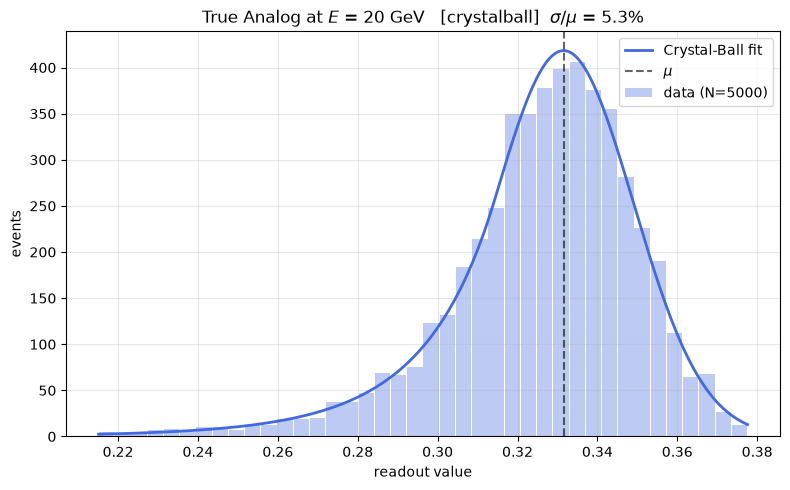

In [5]:
SHOW_METHOD = "Analog"
SHOW_E = E_pts[len(E_pts) // 2]
p = min(points, key=lambda q: abs(q["E"] - SHOW_E))
v = p["obs"][SHOW_METHOD]; r = fit_response(v)
lo, hi = np.percentile(v, [0.3, 99.7])
counts, edges = np.histogram(v, bins=40, range=(lo, hi))
centers = 0.5 * (edges[:-1] + edges[1:]); bw = edges[1] - edges[0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(centers, counts, width=bw * 0.95, color=COLORS[SHOW_METHOD], alpha=0.35, label=f"data (N={v.size})")
xx = np.linspace(lo, hi, 400)
if r["model"] == "crystalball":
    ax.plot(xx, v.size * bw * crystalball.pdf(xx, r["beta"], r["m"], loc=r["mu"], scale=r["sigma"]),
            color=COLORS[SHOW_METHOD], lw=2, label="Crystal-Ball fit")
elif r["model"] == "gaussian":
    ax.plot(xx, v.size * bw * norm.pdf(xx, loc=r["mu"], scale=r["sigma"]),
            color=COLORS[SHOW_METHOD], lw=2, ls="--", label="Gaussian fit")
ax.axvline(r["mu"], color="k", ls="--", alpha=0.6, label=r"$\mu$")
_som = 100 * r["sigma"] / r["mu"] if r["mu"] else float("nan")
ax.set_title(rf"{LABELS[SHOW_METHOD]} at $E$ = {p['E']:.0f} GeV   "
             rf"[{r['model']}]  $\sigma/\mu$ = {_som:.1f}%")
ax.set_xlabel("readout value"); ax.set_ylabel("events"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Fit every (readout, energy), and build the calibration

Loop the scan: for each readout at each energy, fit the response and record the peak $\mu$
(the **calibration** point) and the core width $\sigma$. The $\mu(E)$ curve is the **response
/ calibration curve** — the map from energy to readout. On log-log a linear readout is a
straight line; **flattening is saturation** (a binary pixel struck many times still counts
once). This curvature is the root cause of everything in the resolution plots that follow.

In [6]:
# --- fit every (readout, energy): record the calibration peak mu, core width sigma, its error ---
fit = {m: {"E": [], "mu": [], "sigma": [], "sigma_err": [], "raw": [], "model": []} for m in METHODS}
for p in points:
    for m in METHODS:
        r = fit_response(p["obs"][m])
        if r["ok"] and r["mu"] > 0:
            fit[m]["E"].append(p["E"]); fit[m]["mu"].append(r["mu"])
            fit[m]["sigma"].append(r["sigma"]); fit[m]["sigma_err"].append(r["sigma_err"])
            fit[m]["raw"].append(r["sigma"] / r["mu"]); fit[m]["model"].append(r["model"])
for m in METHODS:
    for k in ("E", "mu", "sigma", "sigma_err", "raw"):
        fit[m][k] = np.asarray(fit[m][k], float)

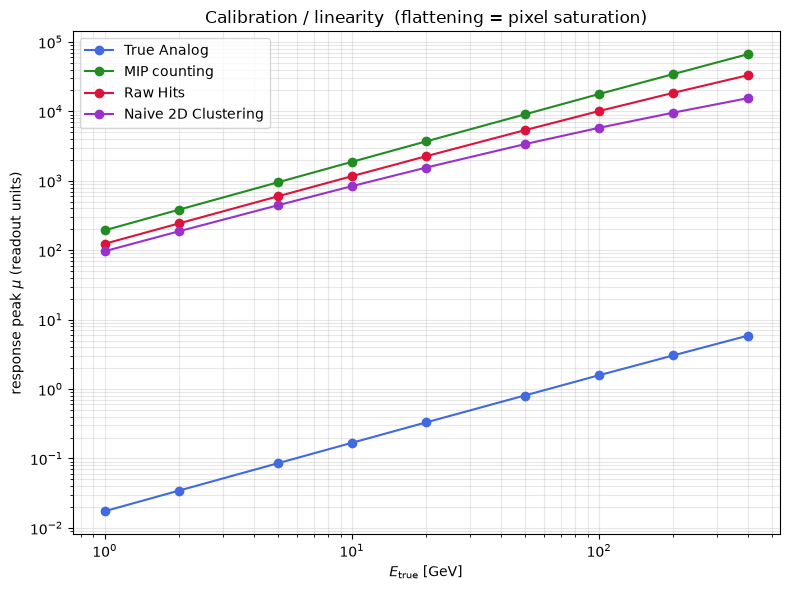

In [7]:
# GIVEN: the calibration / linearity plot
fig, ax = plt.subplots(figsize=(8, 6))
for m in METHODS:
    ax.plot(fit[m]["E"], fit[m]["mu"], "o-", color=COLORS[m], label=LABELS[m])
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$E_{\rm true}$ [GeV]"); ax.set_ylabel(r"response peak $\mu$ (readout units)")
ax.set_title("Calibration / linearity  (flattening = pixel saturation)")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 7. From a readout width to an energy resolution: **invert the calibration**

A width $\sigma$ in *readout units* is not a resolution yet — we want it in **energy**. To
convert, we need the map from readout **back** to energy, i.e. the **inverse of the
calibration** $E_{\rm reco}=\mu^{-1}(\text{readout})$.

**This is the same move nb03 makes, and the parallel is worth seeing:**

| step | nb03 (ML) | this notebook (conventional) |
|---|---|---|
| forward model $E\to$ readout | a neural net, **learned** from a spectrum | the calibration $\mu(E)$, **measured** point-by-point |
| reconstruct energy | invert the learned median curve (root-find) | invert the calibration curve |
| resolution | width of the inverted quantile band | width of the inverted $\mu\pm\sigma$ band |

Same recipe — *build a forward response model, then invert it.* nb03's model is a trained
network; ours is a monotonic curve through the fixed-energy points. Below we build that
inverse (a monotonic PCHIP interpolation) and **show the inversion**: take the readout band
$\mu\pm\sigma$ at one energy and read it back onto the energy axis. *(One nuance in the
parallel: nb03 forms its band via the Neyman crossover — inverting **separate** lower and
upper quantile curves for the two energy-bound edges — whereas here we invert the single
calibration at $\mu\pm\sigma$; the two coincide when the width varies slowly with energy.)*

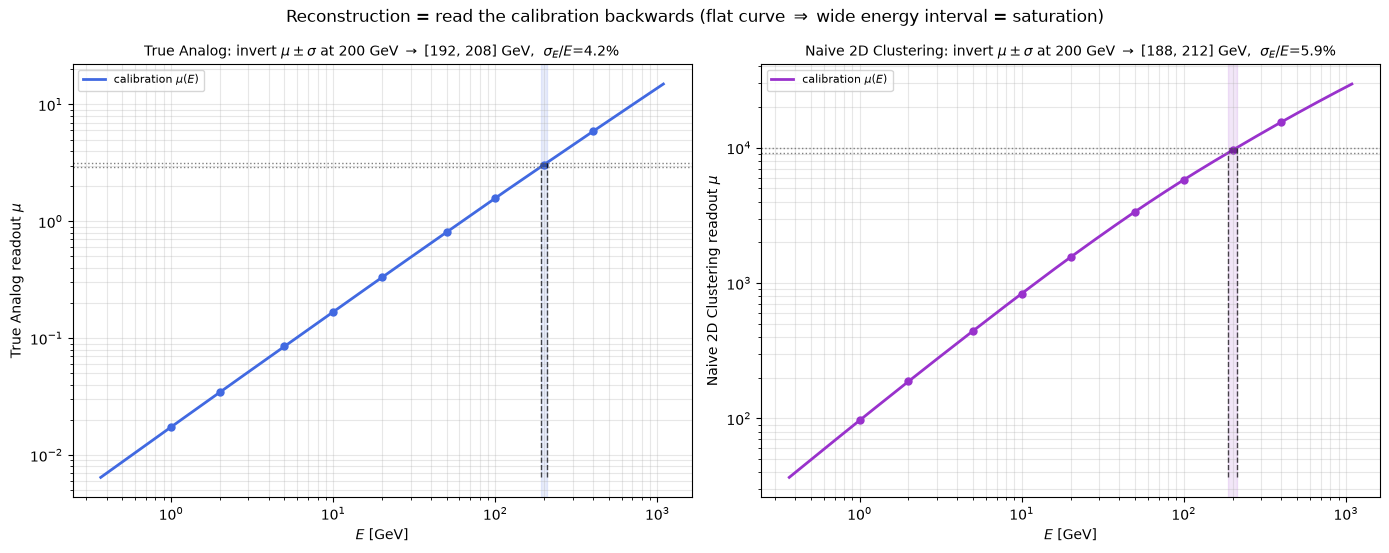

In [8]:
def build_calibration(E, mu, pad=1.0, n=2000):
    """Monotonic calibration mu(E) (PCHIP in log-log) and its inverse ginv(readout)->E.
    ginv extrapolates LINEARLY in log-log beyond the fitted range instead of clamping to the
    grid edge -- so an up-fluctuation mu+sigma above mu(E_max) still inverts to an energy
    above E_max rather than being silently pinned to E_max (which would HIDE the saturation
    the whole notebook is about). Strict monotonicity guarantees a single-valued inverse."""
    E = np.asarray(E, float); mu = np.asarray(mu, float)
    o = np.argsort(E); lE, lmu = np.log(E[o]), np.log(mu[o])
    if np.unique(lE).size < 2:
        raise ValueError("need >= 2 distinct energy points to build a calibration")
    fwd = PchipInterpolator(lE, lmu, extrapolate=True)
    lEg = np.linspace(lE.min() - pad, lE.max() + pad, n)
    lmug = np.maximum.accumulate(fwd(lEg)) + 1e-9 * np.arange(n)   # STRICTLY increasing
    sL = (lEg[1] - lEg[0]) / (lmug[1] - lmug[0])          # boundary slopes for extrapolation
    sR = (lEg[-1] - lEg[-2]) / (lmug[-1] - lmug[-2])
    def ginv(o):
        z = np.log(np.clip(np.asarray(o, float), 1e-30, None))
        r = np.interp(z, lmug, lEg)
        r = np.where(z < lmug[0],  lEg[0]  + (z - lmug[0])  * sL, r)
        r = np.where(z > lmug[-1], lEg[-1] + (z - lmug[-1]) * sR, r)
        return np.exp(r)
    g = lambda E: np.exp(fwd(np.log(np.clip(np.asarray(E, float), 1e-30, None))))
    return g, ginv, np.exp(lEg), np.exp(lmug)

# SHOW the inversion: linear (Analog) vs saturating (Cluster) at a high energy
demoE = E_pts[np.argmin(np.abs(E_pts - 200))]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, m in zip(axes, ["Analog", "Cluster"]):
    E, mu, sig = fit[m]["E"], fit[m]["mu"], fit[m]["sigma"]
    if np.unique(E).size < 2:
        ax.set_title(f"{LABELS[m]}: need >= 2 energy points"); continue
    g, ginv, Eg, mug = build_calibration(E, mu)
    i = int(np.argmin(np.abs(E - demoE))); Ei, mi, si = E[i], mu[i], sig[i]
    Elo, Ehi = float(ginv(mi - si)), float(ginv(mi + si))
    ax.plot(Eg, mug, color=COLORS[m], lw=2, label=r"calibration $\mu(E)$")
    ax.plot(E, mu, "o", color=COLORS[m], ms=5)
    ax.axhline(mi + si, color="gray", ls=":", lw=1); ax.axhline(mi - si, color="gray", ls=":", lw=1)
    ax.plot([Ei, Ei], [mi - si, mi + si], color="k", lw=6, alpha=0.25, solid_capstyle="butt")
    for Ex, my in ((Elo, mi - si), (Ehi, mi + si)):
        ax.plot([Ex, Ex], [mug.min(), my], color="k", ls="--", lw=1, alpha=0.7)
    ax.axvspan(Elo, Ehi, color=COLORS[m], alpha=0.12)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$E$ [GeV]"); ax.set_ylabel(rf"{LABELS[m]} readout $\mu$")
    ax.set_title(rf"{LABELS[m]}: invert $\mu\pm\sigma$ at {Ei:.0f} GeV $\to$ "
                 rf"[{Elo:.0f}, {Ehi:.0f}] GeV,  $\sigma_E/E$={ (Ehi-Elo)/(2*Ei)*100:.1f}%", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
fig.suptitle(r"Reconstruction = read the calibration backwards "
             r"(flat curve $\Rightarrow$ wide energy interval = saturation)", fontsize=12)
plt.tight_layout(); plt.show()

For the **linear** analog readout the inversion barely changes anything —
$\sigma_E/E\approx\sigma/\mu$. For the **digital** readouts it is essential: where the
calibration flattens, a small readout band maps to a *large* energy band, so the true energy
resolution is far worse than the raw count width $\sigma/\mu$ suggests. Quoting $\sigma/\mu$
of the counts would **hide the saturation**. Below we compute both — the naive
$\sigma/\mu$ (dashed) and the honest, inverted $\sigma_E/E$ (solid).

> **The "slope correction," if you have seen it.** Linearizing the inversion gives
> $\sigma_E/E \approx (\sigma/\mu)\,/\,(\mathrm{d}\ln\mu/\mathrm{d}\ln E)$ — dividing the raw
> width by the local slope of the calibration. That is just the first-order Taylor expansion
> of what we do here exactly by inverting the curve.

In [9]:
# --- invert the calibration band mu +/- sigma -> energy interval -> sigma_E/E ---
for m in METHODS:
    E, mu, sig = fit[m]["E"], fit[m]["mu"], fit[m]["sigma"]
    if np.unique(E).size < 2:                       # too few points to invert
        fit[m]["res"] = np.full(np.shape(E), np.nan); continue
    g, ginv, Eg, mug = build_calibration(E, mu)
    fit[m]["res"] = (ginv(mu + sig) - ginv(mu - sig)) / (2.0 * E)   # honest sigma_E/E

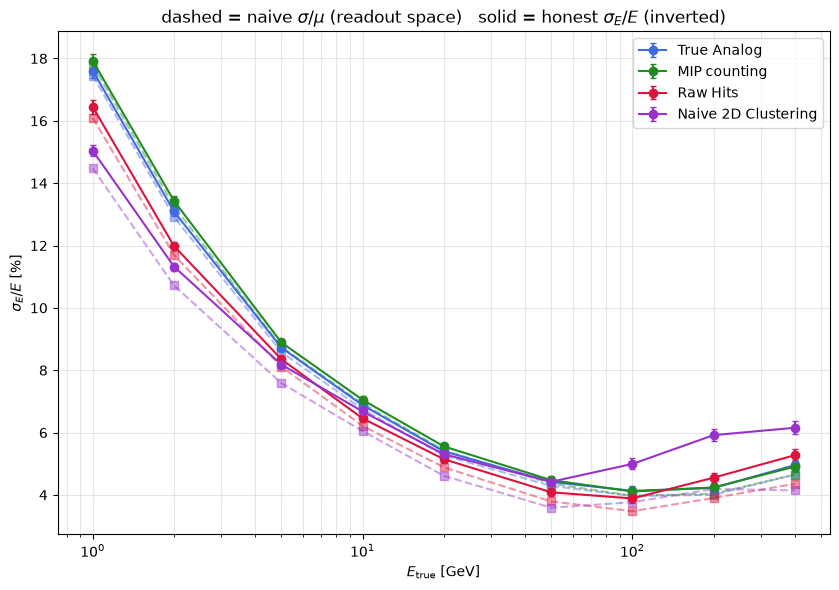

In [10]:
# GIVEN: propagate the fit-width uncertainty to sigma_E/E, then plot naive vs honest
for m in METHODS:
    rel = np.divide(fit[m]["sigma_err"], fit[m]["sigma"],
                    out=np.zeros_like(fit[m]["sigma"]), where=fit[m]["sigma"] > 0)
    fit[m]["res_err"] = fit[m]["res"] * rel        # sigma_E/E scales ~linearly with the width
fig, ax = plt.subplots(figsize=(8.5, 6))
for m in METHODS:
    ax.plot(fit[m]["E"], 100 * fit[m]["raw"], "s--", color=COLORS[m], alpha=0.45)
    ax.errorbar(fit[m]["E"], 100 * fit[m]["res"], yerr=100 * fit[m]["res_err"],
                fmt="o-", color=COLORS[m], capsize=2, label=LABELS[m])
ax.set_xscale("log"); ax.set_xlabel(r"$E_{\rm true}$ [GeV]"); ax.set_ylabel(r"$\sigma_E/E$ [%]")
ax.set_title(r"dashed = naive $\sigma/\mu$ (readout space)   solid = honest $\sigma_E/E$ (inverted)")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 8. The money plot: $\sigma_E/E$ versus $1/\sqrt{E}$

If resolution were purely stochastic, $\sigma_E/E=a/\sqrt{E}$ would be a **straight line
through the origin** against $1/\sqrt{E}$. The standard calorimeter law is
$\sigma_E/E=a/\sqrt{E}\oplus b\oplus c/E$ (stochastic $\oplus$ constant $\oplus$ electronic
noise), but **this simulation has no electronics noise**, so we fit the two-term
$a/\sqrt{E}\oplus b$ — a free $c/E$ would only soak up low-$E$ fit scatter and get mislabelled
"noise". The fit is **weighted by the per-point uncertainties** from §7 (error bars below).
Expect the **analog** readout to track a near-straight line (stochastic-dominated), while the
**digital** readouts peel **upward** at small $1/\sqrt{E}$ (high $E$) as saturation inflates the
constant term $b$. The fitted $a$ (in %·$\sqrt{\rm GeV}$) and $b$ (in %) print below; the top
axis reads back in GeV.

In [11]:
# --- fit sigma_E/E = a/sqrt(E) (+) b  (quadrature; no c/E -- this sim has no noise) ---
def fit_stochastic(E, res, res_err=None):
    def model(E, a, b):
        return np.sqrt((a / np.sqrt(E))**2 + b**2)
    ok = np.isfinite(E) & np.isfinite(res) & (res > 0)
    if ok.sum() < 2: return None, model
    sig = None
    if res_err is not None:
        s = np.asarray(res_err, float)[ok]
        if np.all(np.isfinite(s)) and np.all(s > 0):
            sig = s                                   # weight by the per-point uncertainty
    try:
        p, _ = curve_fit(model, E[ok], res[ok], p0=[0.2, 0.02], sigma=sig,
                         absolute_sigma=sig is not None, bounds=([0, 0], [np.inf, np.inf]),
                         maxfev=40000)
        return p, model
    except Exception:
        return None, model

readout                a [%.sqrt(GeV)]     b [%]
True Analog                       17.3       4.0
MIP counting                      17.7       4.0
Raw Hits                          16.0       3.9
Naive 2D Clustering               14.4       4.8


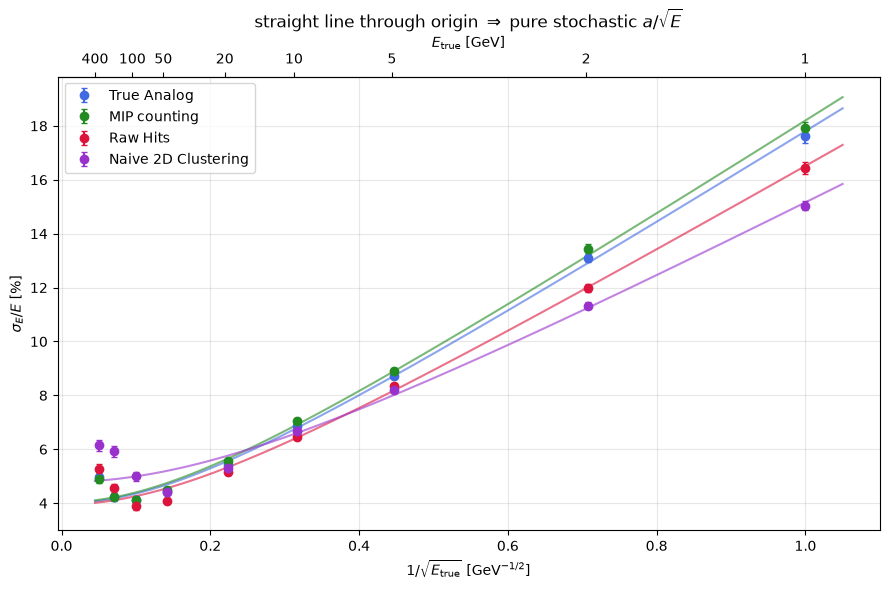

In [12]:
# GIVEN: the sigma_E/E vs 1/sqrt(E) money plot, with the weighted fit overlay + energy axis
fig, ax = plt.subplots(figsize=(9, 6))
print(f"{'readout':<20s}{'a [%.sqrt(GeV)]':>18s}{'b [%]':>10s}")
for m in METHODS:
    E, res = fit[m]["E"], fit[m]["res"]; x = 1.0 / np.sqrt(E)
    ax.errorbar(x, 100 * res, yerr=100 * fit[m]["res_err"], fmt="o", color=COLORS[m],
                capsize=2, label=LABELS[m])
    p, model = fit_stochastic(E, res, fit[m]["res_err"])
    if p is not None:
        xx = np.linspace(x.min() * 0.9, x.max() * 1.05, 200)
        ax.plot(xx, 100 * model(1.0 / xx**2, *p), "-", color=COLORS[m], alpha=0.6)
        print(f"{LABELS[m]:<20s}{100*p[0]:>18.1f}{100*p[1]:>10.1f}")
ax.set_xlabel(r"$1/\sqrt{E_{\rm true}}$ [GeV$^{-1/2}$]"); ax.set_ylabel(r"$\sigma_E/E$ [%]")
ax.set_title(r"straight line through origin $\Rightarrow$ pure stochastic $a/\sqrt{E}$")
def _to_e(x):   return 1.0 / np.clip(np.asarray(x, float), 1e-6, None)**2
def _from_e(E): return 1.0 / np.sqrt(np.clip(np.asarray(E, float), 1e-6, None))
sec = ax.secondary_xaxis("top", functions=(_to_e, _from_e))
sec.set_xlabel(r"$E_{\rm true}$ [GeV]"); sec.set_xticks([400, 100, 50, 20, 10, 5, 2, 1])
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Conventional vs ML resolution — when to use which

You have now measured the DECAL energy resolution two completely different ways. They are
worth contrasting.

| | **Conventional (this notebook)** | **ML surrogate ([nb03](03_ml_training_and_eval.ipynb))** |
|---|---|---|
| input data | dedicated **fixed-energy** runs (more simulation) | one **continuous spectrum** run |
| model | a Crystal-Ball fit per energy + a calibration curve | a trained neural quantile ensemble |
| what "resolution" is | core σ of the response, **inverted** to energy | half-width of the learned Neyman band |
| compute | a few `curve_fit`s, seconds, no GPU | ensemble training on a GPU |
| transparency | every step readable by eye; **ground truth** | powerful but a surrogate; harder to audit |
| energy coverage | only the energies you simulated (discrete) | the whole continuum at once |
| main risk | assumes a fit form; needs enough stats per point | needs enough spectrum coverage; can extrapolate blindly |

Neither is "better" — they answer the same question from opposite directions, which is
exactly why running both is valuable:

- **Compare like-for-like.** One caveat before overlaying: this notebook quotes the
  Crystal-Ball **Gaussian-core** $\sigma$, which *excludes* the low-side leakage tail, whereas
  nb03's Neyman band is a central-quantile interval that *includes* it. So the conventional
  $\sigma_E/E$ here is systematically **≤** nb03's band wherever there is a tail — a
  definitional offset, not a physics disagreement. What should genuinely match is the
  **shape**: the $1/\sqrt{E}$ scaling, the ordering of the four readouts, and the
  low-E-digital-wins / high-E-digital-saturates crossover. For a strict number-to-number
  check, quote both from the *same* central-68% interval (replace the core $\sigma$ with
  $(P_{84}-P_{16})/2$, which includes the tail).
- **Where they diverge is physics, not error.** At very low energy (few counts, discrete,
  non-Gaussian) the Crystal-Ball assumptions strain; deep in saturation the calibration is
  nearly flat and *both* the inversion here and the Neyman inversion in nb03 become sensitive
  — that sensitivity is the real message (the readout is running out of information), not a
  numerical artifact.

**Takeaways from the plots above:**

- **Analog** is the benchmark: linear calibration, near-straight $\sigma_E/E$ vs
  $1/\sqrt{E}$, small constant term — the "$1/\sqrt{E}$ is a straight line" intuition made real.
- **Digital readouts** (MIP → Hits → Cluster) trade the analog Landau tail for a
  **saturation** problem that grows with energy; the naive clustering saturates earliest. At
  **low** energy binary counting can actually *win* (it truncates the Landau tail).
- The **inversion** in §7 is what separates a naive "width of the count" from a real energy
  resolution — and it is the exact conventional counterpart of nb03's neural reconstruction.

> **Extend it.** Re-run §0–§8 for `PARTICLE = "pi+"` and watch the method **strain**. This is
> an EM calorimeter (~28 $X_0$ but only ~1.6 nuclear interaction lengths), so many pions punch
> through as minimum-ionizing or interact late: the response goes **bimodal** — a
> punch-through peak plus a shower tail — instead of a single Gaussian core, and a single-peak
> Crystal-Ball fit no longer captures "the resolution." That breakdown is the lesson — hadronic
> calorimetry needs a different detector (more $\lambda_I$) and a different analysis. And when
> you improve the clusterer (nb03's capstone), the photon saturation knee here should move to
> higher energy.